In [1]:
import pylbsr.notebooks
import pylbsr.misc

import pandas as pd
import matplotlib.pyplot as plt

import functools
import torch
import torch.nn as nn
import torch.utils.data
import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger
from dotmap import DotMap
from pathlib import Path
import yaml
from typing import Literal

import parnet
from parnet.layers import (
    AdditiveMix,
    LinearProjectionHead,
    MixCoeffMLP,
    MixCoeffPenalty,
)
from parnet.losses import MultinomialNLLLoss
from parnet.bin.train import LightningModel
from parnet_additional_utils import (
    load_parnet_model,
    load_parnet_model_from_statedict,
    ParnetModelName,
    save_parnet_model_as_statedict,
    GzListDataset,
)
from parnet.utils import count_trainable_params

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


In [2]:
_notebook_name = "02_train_globalclip_head.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[07:57:01] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [3]:
### SETUP

pylbsr.misc.set_seed(42)

torch.use_deterministic_algorithms(False)  # dilated convs have no deterministic CUDA kernel

params_gpu_index = 0
device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[07:57:04] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.17 s (00:00:00)


In [6]:
### PARAMETERS

# ── Task / data configuration ──────────────────────────────────────────────────
params_num_tasks = 1        # single globalCLIP track
params_seq_length = 600

params_valid_split: str = "valid"
params_use_filtered_data: bool = True


# ── Model ─────────────────────────────────────────────────────────────────────
pretrained_model_name = ParnetModelName.PARNET_21M_5_0   # or PARNET_21M_NONE / PARNET_21M_5_0 / PARNET_7M_0_0
_model_tag = pretrained_model_name.value.replace("parnet.", "")   # "21m-5.0" or "21m-none" or "7m-0.0"

# ── Fine-tuning strategy ───────────────────────────────────────────────────────
params_finetuning_strategy: Literal["head", "unfreeze_last_n_layers", "full"] = "unfreeze_last_n_layers"
params_use_control: bool = False   # Phase 1: no control
params_unfreeze_last_layers_n: int = 2

# ── Training ──────────────────────────────────────────────────────────────────
params_batch_size: int = 64
params_max_epochs: int = 50
params_lr: float = 1e-3

# ── Run naming ────────────────────────────────────────────────────────────────
_ctrl_suffix = "ctrl" if params_use_control else "noctrl"
_data_suffix = "filtered" if params_use_filtered_data else "raw"

_strategy_suffix = (
    f"unfreeze_last_{params_unfreeze_last_layers_n}_layers"
    if params_finetuning_strategy == "unfreeze_last_n_layers"
    else params_finetuning_strategy
)
params_name_of_resulting_model = (
    f"parnet.{_model_tag}"
    f".{_strategy_suffix}"
    f".globalclip-lysate-noNHS"
    f".{_data_suffix}"
    f".{_ctrl_suffix}"
    f".ep{params_max_epochs}"
)

⏱ 0.00 s (00:00:00)


In [22]:
### LOAD FILEPATHS CONFIG

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p

FILEPATHS = DotMap()

if params_use_filtered_data:
    FILEPATHS["data"] = _res(_fp_cfg["global_clip"]["data_lysate_noNHS_filtered"])
else:
    FILEPATHS["data"] = _res(_fp_cfg["global_clip"]["data_lysate_noNHS"])
    
FILEPATHS["pretrained_model"] = _res(_fp_cfg["models"][pretrained_model_name.value])
FILEPATHS["output_dir"] = (
    PROJECT_DIR / "results" / "globalclip-head"
    / "training" / params_name_of_resulting_model
)

FILEPATHS["figures_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "figures"
FILEPATHS["figures_dir"].mkdir(parents=True, exist_ok=True)

logger.info(f"Data:             {FILEPATHS.data}")
logger.info(f"Pretrained model: {FILEPATHS.pretrained_model}")
logger.info(f"Output dir:       {FILEPATHS.output_dir}")

FIGURES_DIR = PROJECT_DIR / "results" / "globalclip-head" / "figures"

[09:29:52] INFO - Data:             /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/datasets/globalclip_lysate_noNHS.minreads3.maxsignal1000.pt
INFO:02_train_globalclip_head.ipynb:Data:             /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/datasets/globalclip_lysate_noNHS.minreads3.maxsignal1000.pt
[09:29:52] INFO - Pretrained model: /mnt/storage1/ml4rg26-shared/parnet-eclip/models-full-rbp-set/parnet.21m-5.0.pt
INFO:02_train_globalclip_head.ipynb:Pretrained model: /mnt/storage1/ml4rg26-shared/parnet-eclip/models-full-rbp-set/parnet.21m-5.0.pt
[09:29:52] INFO - Output dir:       /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50
INFO:02_train_globalclip_head.ipynb:Output dir:       /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_la

⏱ 0.03 s (00:00:00)


In [8]:
### SAVE RUN CONFIG FILE

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
_run_cfg = {
    "pretrained_model_name": pretrained_model_name.value,
    "params_finetuning_strategy": params_finetuning_strategy,
    "params_unfreeze_last_layers_n": params_unfreeze_last_layers_n,
    "params_use_control": params_use_control,
    "params_batch_size": params_batch_size,
    "params_max_epochs": params_max_epochs,
    "params_lr": params_lr,
    "params_seq_length": params_seq_length,
    "params_num_tasks": params_num_tasks,
    "params_valid_split": params_valid_split,
    "params_name_of_resulting_model": params_name_of_resulting_model,
    "dataset_path": str(FILEPATHS["data"]),
}
_run_cfg_path = FILEPATHS["output_dir"] / "run_config.yaml"
_run_cfg_path.write_text(yaml.dump(_run_cfg, default_flow_style=False))
logger.info(f"Saved run config → {_run_cfg_path}")

[08:02:11] INFO - Saved run config → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/run_config.yaml


⏱ 0.01 s (00:00:00)


In [9]:
### DATASET PREPARATION

train_ds = GzListDataset(
    FILEPATHS.data, split="train",
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=True, mmap=True,
)
val_ds = GzListDataset(
    FILEPATHS.data, split=params_valid_split,
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)

logger.info(f"Train size: {len(train_ds)}  |  Val size: {len(val_ds)}")

Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='train'... loaded 38695 samples.
Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='valid'... 

[08:02:34] INFO - Train size: 38695  |  Val size: 7266


loaded 7266 samples.
⏱ 19.24 s (00:00:19)


In [10]:
### LOAD PRETRAINED MODEL

model = load_parnet_model(
    pretrained_model_name,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)
logger.info(f"Loaded pretrained model — trainable params: {count_trainable_params(model):,}")
_head_conv = getattr(model.head.head_target, "pointwise", None) or getattr(
    model.head.head_target, "pointwise_conv", None
)
logger.info(f"Pretrained head num_tasks: {_head_conv.out_channels}")

[08:02:39] INFO - Loaded pretrained model — trainable params: 21,814,495
[08:02:39] INFO - Pretrained head num_tasks: 223


⏱ 0.58 s (00:00:00)


In [11]:
### MODEL ADAPTATION

class GlobalCLIPHead(nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        # (B, hidden_dim, 600) -> (B, num_tasks, 600)
        logit = self.projection(inputs)
        # normalize to log-probabilities along sequence dimension
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model.head = GlobalCLIPHead(num_tasks=params_num_tasks).to(device)

# initialize lazy parameters — derive hidden dim from the backbone (512 for 7M, 768 for 21M)
with torch.no_grad():
    _probe_seq = train_ds[0]["inputs"]["sequence"].unsqueeze(0).to(device)
    _backbone_out = model.body(model.stem(_probe_seq))
    _hidden_dim = _backbone_out.shape[1]
    model.head(_backbone_out)

logger.info(f"Backbone hidden dim: {_hidden_dim}")
logger.info(f"Replaced head — trainable params now: {count_trainable_params(model):,}")
print(model.head)
logger.info(f"New head out_channels: {model.head.projection.pointwise.out_channels}")

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
[08:02:49] INFO - Backbone hidden dim: 768
[08:02:49] INFO - Replaced head — trainable params now: 21,301,248
[08:02:49] INFO - New head out_channels: 1


GlobalCLIPHead(
  (projection): LinearProjectionHead(
    (pointwise): Conv1d(768, 1, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
)
⏱ 0.96 s (00:00:00)


In [12]:
### FINETUNING STRATEGY

if params_finetuning_strategy == "head":
    for param in model.stem.parameters():
        param.requires_grad = False
    for param in model.body.parameters():
        param.requires_grad = False
    print(f"[head] Trainable params: {count_trainable_params(model):,}  (head only)")

elif params_finetuning_strategy == "unfreeze_last_n_layers":
    for param in model.parameters():
        param.requires_grad = False
    body_blocks = list(model.body.children())
    for block in body_blocks[-params_unfreeze_last_layers_n:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.head.parameters():
        param.requires_grad = True
    print(
        f"[unfreeze_last_{params_unfreeze_last_layers_n}_layers] "
        f"Trainable params: {count_trainable_params(model):,}"
    )

elif params_finetuning_strategy == "full":
    for param in model.parameters():
        param.requires_grad = True
    print(f"[full] Trainable params: {count_trainable_params(model):,}")

# when using params_finetuning_strategy = "head", you should see a very small number — 
# just the 512 weights of the Conv1d(512, 1, kernel_size=1) in our head

[unfreeze_last_2_layers] Trainable params: 3,544,320
⏱ 0.00 s (00:00:00)


In [13]:
### TENSORBOARD LOGGING

%load_ext tensorboard
_tb_logdir = str(FILEPATHS["output_dir"] / "tensorboard_logs")
%tensorboard --logdir {_tb_logdir}

Launching TensorBoard...

⏱ 10.04 s (00:00:10)


In [14]:
### TRAINING SETUP

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)

optimizer_cls = functools.partial(torch.optim.AdamW, lr=params_lr)
lightning_model = LightningModel(
    model=model,
    loss_fn=MultinomialNLLLoss(),
    optimizer=optimizer_cls,
    use_control=False, # only affects metric logging, not the forward pass
)

⏱ 0.01 s (00:00:00)


In [15]:
from parnet_demo_utils import MetricHistory

metric_history = MetricHistory()

csv_logger = CSVLogger(save_dir=FILEPATHS["output_dir"], name="csv_logs")
tb_logger  = TensorBoardLogger(save_dir=FILEPATHS["output_dir"], name="tensorboard_logs")

trainer = pl.Trainer(
    default_root_dir=FILEPATHS["output_dir"],
    max_epochs=params_max_epochs,
    accelerator="gpu",
    devices=[params_gpu_index],
    log_every_n_steps=10,
    logger=[csv_logger, tb_logger],
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=FILEPATHS["output_dir"] / "checkpoints",
            monitor="val/loss",
            mode="min",
            save_top_k=1,
            save_last=True,
            filename="best",
        ),
        metric_history,
    ],
)

trainer.fit(
    lightning_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=None,  # or specify a checkpoint path to resume training, e.g. best.ckpt
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2026-07-04 08:04:50.210073: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-04 08:04:50.222773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-04 08:04:50.241696: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-04 08:04:50.241732: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been r

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric MeanMetric was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)
/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:527: Found 55 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


⏱ 4669.49 s (01:17:49)


In [18]:
# ── Export best model ──────────────────────────────────────────────────────────
# Load best checkpoint (lowest val/loss) rather than last epoch weights
best_ckpt_path = FILEPATHS["output_dir"] / "checkpoints" / "best.ckpt"
best_checkpoint = torch.load(best_ckpt_path, map_location=device)
lightning_model.load_state_dict(best_checkpoint["state_dict"])
logger.info(f"Loaded best checkpoint from → {best_ckpt_path}")

output_model_path = FILEPATHS["output_dir"] / "model.statedict.pt"
torch.save({
    "state_dict": lightning_model.model.state_dict(),
    "model_config": {
        "parnet_model_name": pretrained_model_name.value,
        "head": "GlobalCLIPHead",
        "num_tasks": params_num_tasks,
        "finetuning_strategy": params_finetuning_strategy,
        "use_control": params_use_control,
    },
}, output_model_path)
logger.info(f"Saved best model → {output_model_path}")

[09:28:37] INFO - Loaded best checkpoint from → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/checkpoints/best.ckpt
INFO:02_train_globalclip_head.ipynb:Loaded best checkpoint from → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/checkpoints/best.ckpt
[09:28:38] INFO - Saved best model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt
INFO:02_train_globalclip_head.ipynb:Saved best model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.21m-5.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt


⏱ 1.99 s (00:00:01)


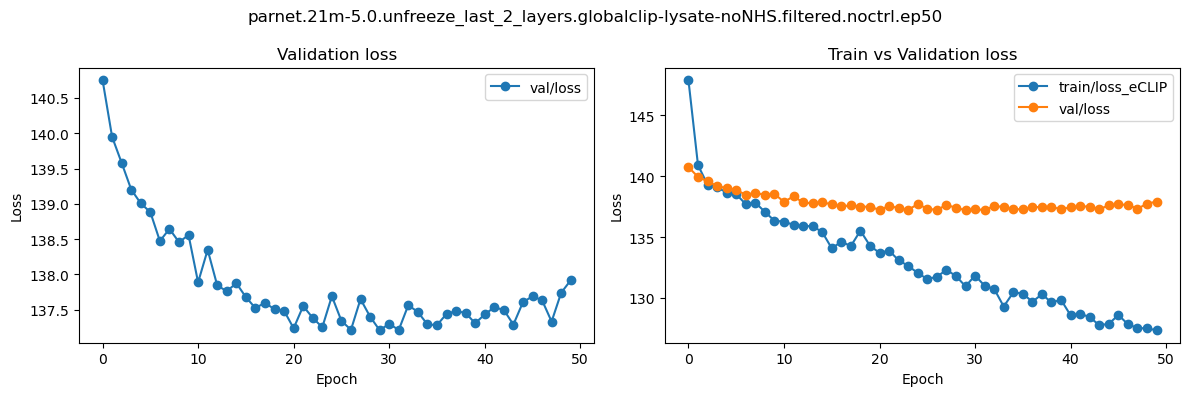

⏱ 0.56 s (00:00:00)


In [20]:
### LOSS CURVES

import pandas as pd
import matplotlib.pyplot as plt

_csv_path = sorted((FILEPATHS["output_dir"] / "csv_logs").glob("version_*/metrics.csv"))[-1]
df = pd.read_csv(_csv_path)

val   = df[['epoch', 'val/loss']].dropna(subset=['val/loss'])
train = df[['epoch', 'train/loss_eCLIP_epoch']].dropna(subset=['train/loss_eCLIP_epoch'])
summary = val.merge(train, on='epoch')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary['epoch'], summary['val/loss'], marker='o', label='val/loss')
axes[0].set_title('Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(summary['epoch'], summary['train/loss_eCLIP_epoch'], marker='o', label='train/loss_eCLIP')
axes[1].plot(summary['epoch'], summary['val/loss'], marker='o', label='val/loss')
axes[1].set_title('Train vs Validation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle(params_name_of_resulting_model)
plt.tight_layout()

# ── Save to run folder and central figures dir ─────────────────────────────────
_figures_dir = PROJECT_DIR / "results" / "globalclip-head" / "figures"
_figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(FILEPATHS["output_dir"] / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.savefig(_figures_dir / f"loss_curves.{params_name_of_resulting_model}.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# ── Compute trainable params per configuration ─────────────────────────────────
import torch
from parnet_additional_utils import load_parnet_model, ParnetModelName
from parnet.layers import LinearProjectionHead
from parnet.utils import count_trainable_params

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

class GlobalCLIPHead(torch.nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)
    def forward(self, inputs, **kwargs):
        logit = self.projection(inputs)
        return {"total": logit - torch.logsumexp(logit, dim=-1, keepdim=True),
                "mix_coeff": torch.ones(inputs.shape[0], 1, device=inputs.device)}

def count_params(model_enum, strategy, n_layers=2):
    model = load_parnet_model(model_enum, Path(_fp_cfg["models"][model_enum.value]),
                              dtype=torch.float32, device=device)
    model.head = GlobalCLIPHead(1).to(device)
    # init lazy head from a real backbone pass
    with torch.no_grad():
        probe = torch.zeros(1, 4, 600, device=device)
        model.head(model.body(model.stem(probe)))
    # apply freezing
    if strategy == "head":
        for p in model.stem.parameters(): p.requires_grad = False
        for p in model.body.parameters(): p.requires_grad = False
    elif strategy == "unfreeze_last_n_layers":
        for p in model.parameters(): p.requires_grad = False
        for block in list(model.body.children())[-n_layers:]:
            for p in block.parameters(): p.requires_grad = True
        for p in model.head.parameters(): p.requires_grad = True
    return count_trainable_params(model)

configs = [
    ("7M",  ParnetModelName.PARNET_7M_0_0,  "head", None),
    ("7M",  ParnetModelName.PARNET_7M_0_0,  "unfreeze_last_n_layers", 2),
    ("7M",  ParnetModelName.PARNET_7M_0_0,  "unfreeze_last_n_layers", 5),
    ("21M", ParnetModelName.PARNET_21M_5_0, "unfreeze_last_n_layers", 2),
]

rows = []
for size, enum, strat, n in configs:
    tp = count_params(enum, strat, n or 2)
    label = f"{strat}" + (f"_{n}" if n else "")
    rows.append({"model": size, "config": label, "trainable_params": f"{tp:,}"})

params_df = pd.DataFrame(rows)
print(params_df.to_string(index=False))
params_df.to_csv(FIGURES_DIR / "trainable_params.csv", index=False)

model                   config trainable_params
   7M                     head              512
   7M unfreeze_last_n_layers_2        1,576,448
   7M unfreeze_last_n_layers_5        3,940,352
  21M unfreeze_last_n_layers_2        3,544,320
⏱ 1.52 s (00:00:01)
